In [1]:
# Gõ dòng này vào cell đầu tiên và bấm Run (Shift + Enter) or Run All
get_ipython().run_line_magic('run', '../_setup.py')

In [13]:
from functools import partial

from matplotlib.ticker import MaxNLocator
from statsforecast import StatsForecast
from statsforecast.arima import ARIMASummary
from statsforecast.models import AutoARIMA
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox
from utilsforecast.feature_engineering import trend, fourier, pipeline
from utilsforecast.processing import make_future_dataframe

In [3]:
BASE_DIR = Path.cwd().parent.parent
DATA_DIR = BASE_DIR / "data"
print(DATA_DIR)

/home/phu/Documents/GitHub/-Time-Series-Analysis-and-Forecasting-methods-/data


# Exercises for Chapter 10

### 1. This exercise uses data set `LakeHuron` giving the level of Lake Huron from 1875–1972.

a. Load and plot the data.

b. Fit a linear trend model to the Lake Huron data with an ARMA error structure.

c. Forecast the level for the next 30 years. Do you think the extrapolated linear trend is realistic?

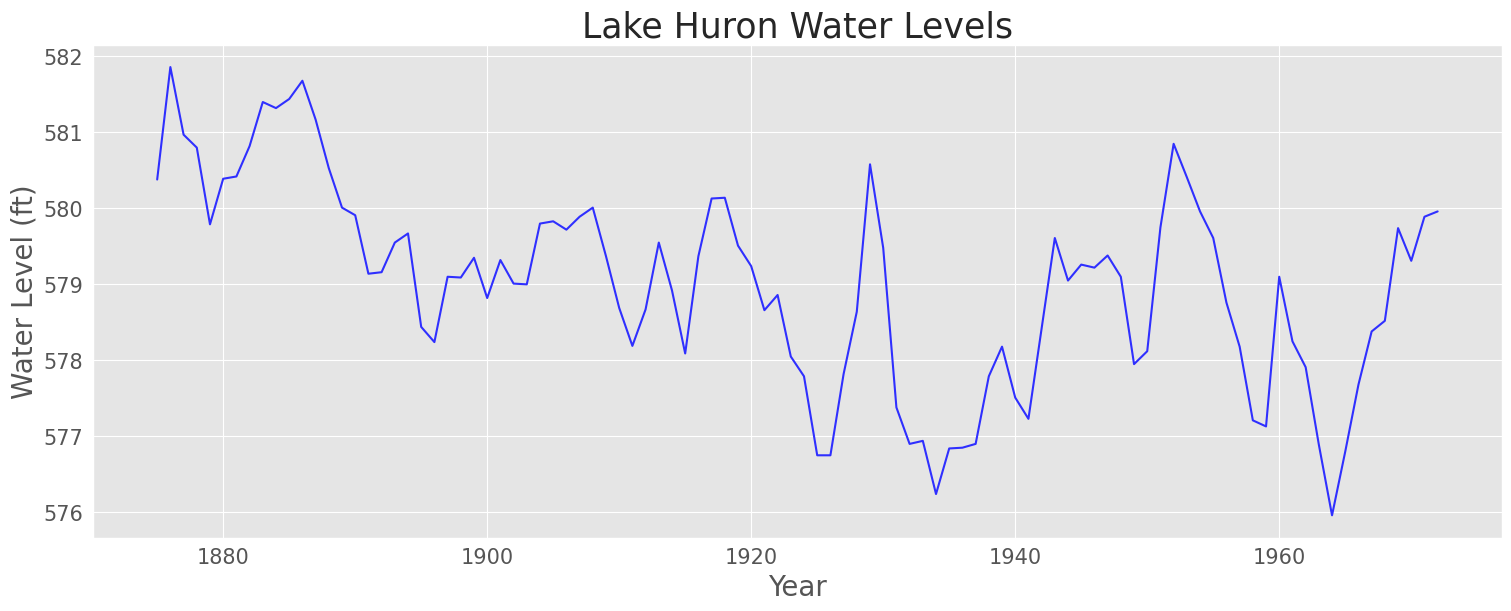

In [ ]:
df = pd.read_csv(DATA_DIR / 'lake_huron.csv', parse_dates=['ds'])

fig = plot_series(df, title='Lake Huron Water Levels', xlabel='Year', ylabel='Water Level (ft)',)
display(fig)

In [10]:
models = [AutoARIMA()]
sf = StatsForecast(models=models, freq='YS', n_jobs=1)
sf.fit(df=df, target_col='y')

model = sf.fitted_[0, 0].model_
# items = list(model["coef"].items())
# arma = pd.Series(dict(items[:3]), name="ARMA Coefficients").round(3)
# regr = pd.Series(dict(items[3:]), name="Regression Coefficients").round(3)
# metrics = pd.Series({
#     "sigma^2": model["sigma2"], "loglik": model["loglik"],
#     "aic": model["aic"], "aicc": model["aicc"], "bic": model["bic"],
# }, name="Metrics").round(2)
print(ARIMASummary(model), "\n")
# print(arma.to_frame(), "\n")
# print(regr.to_frame(), "\n")
# print(metrics.to_frame())

ARIMA(0,1,0)                    



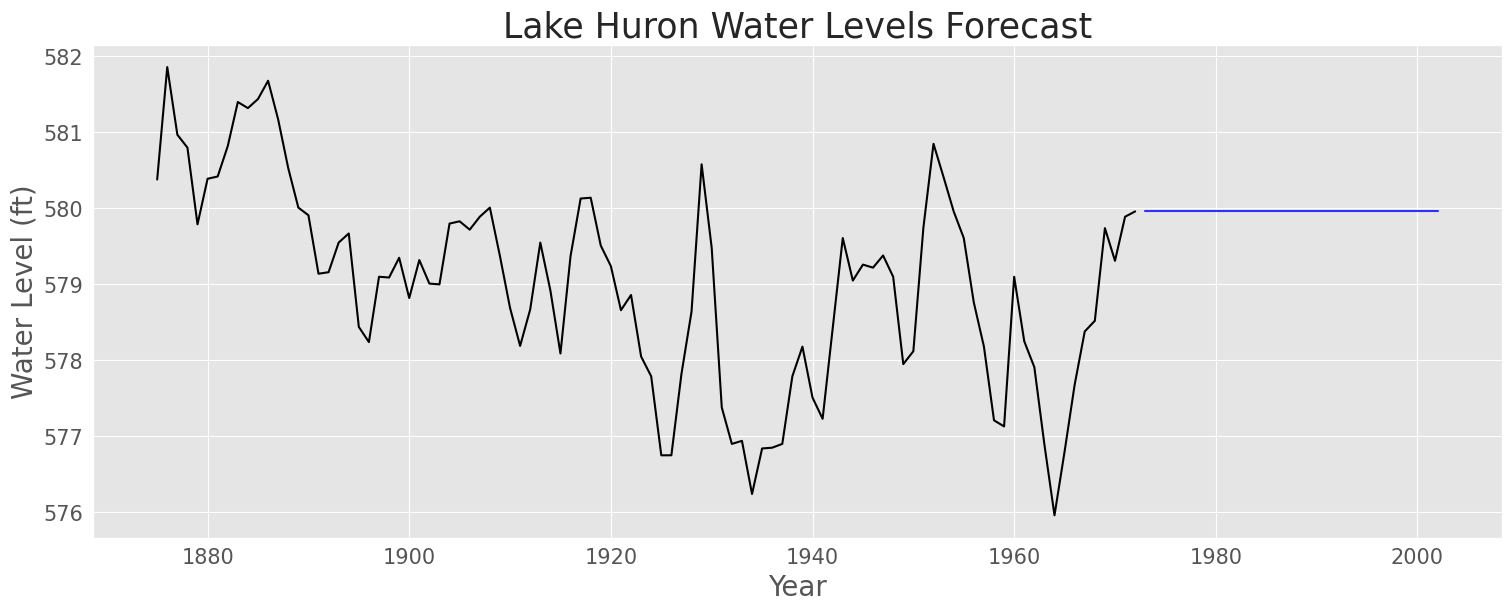

In [17]:
forecasts = sf.forecast(df=df, h=30)

plot_series(df, forecasts, title='Lake Huron Water Levels Forecast', xlabel='Year', ylabel='Water Level (ft)',)

Because datasets doesn't have any exogenous variables, so the linear line is not realistic to perform the trend or the seasonality

### 2. Repeat Exercise 4 from Section 7.10, but this time adding in ARIMA errors to address the autocorrelations in the residuals.

a. How much difference does the ARIMA error process make to the forecasts?

b. Check the residuals of the ARIMA model to ensure it has adequately addressed the autocorrelations in the data.

### 3. Repeat the daily electricity example, but add an indicator variable called `Temperature2` with a value of 1 when the temperature is equal or greater than 25 degree Celsius, and zero otherwise.

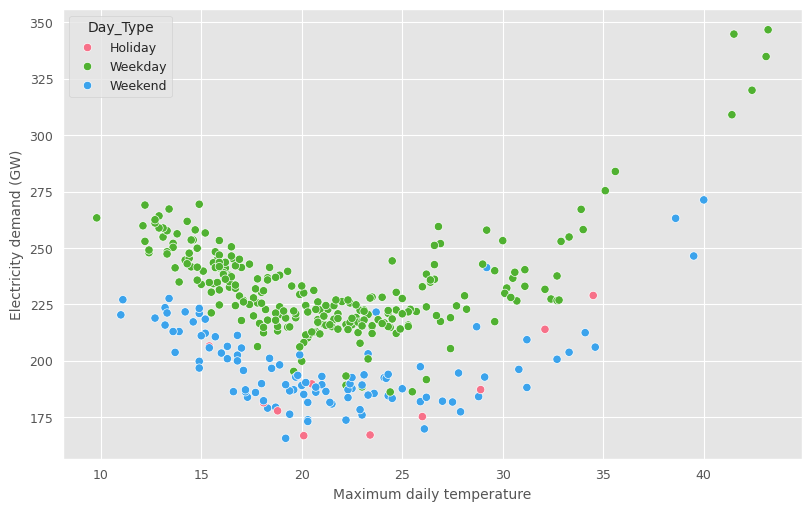

In [27]:
vic_elec = (
    pd.read_csv(DATA_DIR / 'vic_elec.csv', parse_dates=['ds'])
    .loc[lambda x: x["ds"] >= "2014"]
    .pivot(index=["ds", "Holiday"], columns="unique_id", values="y")
    .reset_index(level="Holiday").rename_axis(None, axis="columns")
)
vic_elec_daily = (
    vic_elec
    .resample("D")
    .agg({"Demand": "sum", "Temperature": "max", "Holiday": "first"})
    .reset_index()
    .assign(
        unique_id="VIC",
        Demand=lambda x: x["Demand"] / 1e3,
        Weekend=lambda x: x["ds"].dt.dayofweek.isin([5, 6]),
        Day_Type=lambda x: np.select(
            [x["Holiday"], ~x["Holiday"] & x["Weekend"]],
            ["Holiday", "Weekend"],
            default="Weekday",
        ),
        Temperature2=lambda x: (x['Temperature'] >= 25).astype(int)
    )
)

fig, ax = plt.subplots()
sns.scatterplot(data=vic_elec_daily,
  x="Temperature", y="Demand", hue="Day_Type")
ax.set(
  xlabel="Maximum daily temperature", ylabel="Electricity demand (GW)"
)
plt.show()

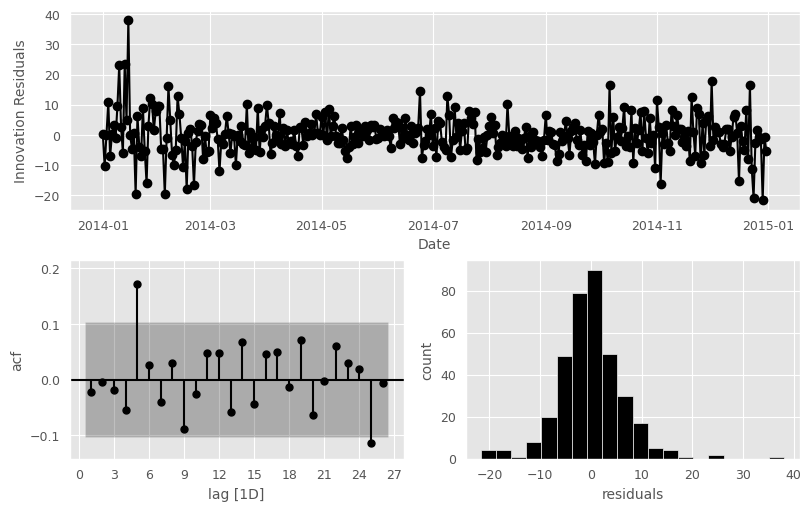

In [29]:
sf = StatsForecast(models=[AutoARIMA(season_length=7)], freq="D")
ex_columns = ["unique_id", "ds", "Demand", "Temperature", "Temperature2"]
vic_elec_daily_ex = vic_elec_daily[ex_columns].assign(**{
    "Weekday": vic_elec_daily["Day_Type"] == "Weekday",
    "Temperature**2": vic_elec_daily["Temperature"]**2,
})

sf = sf.fit(df=vic_elec_daily_ex, target_col="Demand")
resids = sf.fitted_[0, 0].model_["residuals"]

fig, axes = plt.subplot_mosaic([["resid", "resid"], ["acf", "hist"]])
axes["resid"].plot(vic_elec_daily["ds"], resids, marker="o")
axes["resid"].set(xlabel="Date", ylabel="Innovation Residuals")
plot_acf(resids, axes["acf"], zero=False, auto_ylims=True,
    bartlett_confint=False)
axes["acf"].xaxis.set_major_locator(MaxNLocator(integer=True))
axes["acf"].set(xlabel="lag [1D]", ylabel="acf", title="")
axes["hist"].hist(resids, bins=20)
axes["hist"].set(xlabel="residuals", ylabel="count")
plt.show()

In [30]:
model = sf.fitted_[0, 0].model_
items = list(model["coef"].items())
arma = pd.Series(dict(items[:8]), name="ARMA Coefficients").round(3)
regr = pd.Series(dict(items[8:]), name="Regression Coefficients").round(3)
metrics = pd.Series({
    "sigma^2": model["sigma2"],
    "loglik": model["loglik"],
    "aic": model["aic"],
    "aicc": model["aicc"],
    "bic": model["bic"],
}, name="Metrics").round(2)
print(ARIMASummary(model), "\n")
print(arma.to_frame(), "\n")
print(regr.to_frame(), "\n")
print(metrics.to_frame())

Regression with ARIMA(2,1,2)(2,0,2)[7] errors 

      ARMA Coefficients
ar1              -0.085
ar2               0.715
ma1              -0.025
ma2              -0.912
sar1              0.309
sar2              0.567
sma1             -0.164
sma2             -0.390 

      Regression Coefficients
ex_1                   -7.517
ex_2                    0.489
ex_3                   29.317
ex_4                    0.177 

         Metrics
sigma^2    43.16
loglik  -1197.28
aic      2420.56
aicc     2421.60
bic      2471.22


The fitted model has 4 coefficients and an ARIMA(2,1,2)(2,0,2)[7] error, so there are 8 AR and MA coefficients.

In [31]:
ljung_box = acorr_ljungbox(resids, lags=[14], model_df=8)
ljung_box

,lb_stat,lb_pvalue
14,21.647,0.001


### 4. This exercise concerns `aus_accommodation`: the total quarterly takings from accommodation and the room occupancy level for hotels, motels, and guest houses in Australia, between January 1998 and June 2016. Total quarterly takings are in millions of Australian dollars.

a. Compute the CPI-adjusted takings and plot the result for each state

b. For each state, fit a dynamic regression model of CPI-adjusted takings with seasonal dummy variables, a linear trend model and ARIMA errors.

c. Check that the residuals of the ARIMA model look like white noise.

d. Forecast the takings for each state to the end of 2017. (Hint: You will need to produce forecasts of the CPI first.)

e. What sources of uncertainty have not been taken into account in the prediction intervals?



In [60]:
df = (
    pd.read_csv(DATA_DIR / 'aus_accomodation.csv', parse_dates=['ds'])
    .assign(CPI_adjusted = lambda x: x['Takings'] * (x['CPI'] / x['CPI'].iloc[0]))
    )

ids = df["unique_id"].unique()
# for id_ in ids:
#     df_id = df.loc[df["unique_id"] == id_]
#     fig = plot_series(df_id, target_col = 'CPI_adjusted', title=f'Accommodation Takings in {id_}', xlabel='Year', ylabel='Takings (CPI Adjusted)')
#     display(fig)

In [68]:
models = {}
for id_ in ids: 
    df_id = df.loc[df["unique_id"] == id_]

    df_id['trend'] = df_id.groupby('unique_id').cumcount() + 1
    train_df = df_id[['unique_id', 'ds', 'CPI_adjusted']].rename(columns={'CPI_adjusted': 'y'})

    models = AutoARIMA(season_length=4)
    sf = StatsForecast(models=[models], freq='QS', n_jobs=1)
    res = sf.fit(train_df, target_col='y')

    # model 
    fitted_model = sf.fitted_[0, 0].model_
    print(f"State: {id_} | Fitted model: {ARIMASummary(fitted_model)}")

    # check residuals 
    resids = sf.fitted_[0, 0].model_["residuals"]

    # fig, axes = plt.subplot_mosaic([["resid", "resid"], ["acf", "hist"]])
    # axes["resid"].plot(train_df["ds"], resids, marker="o")
    # axes["resid"].set(xlabel="Date", ylabel="Innovation Residuals")
    # plot_acf(resids, axes["acf"], zero=False, auto_ylims=True,
    #     bartlett_confint=False)
    # axes["acf"].xaxis.set_major_locator(MaxNLocator(integer=True))
    # axes["acf"].set(xlabel="lag [1D]", ylabel="acf", title="")
    # axes["hist"].hist(resids, bins=20)
    # axes["hist"].set(xlabel="residuals", ylabel="count")
    # plt.show()
    

State: Australian Capital Territory | Fitted model: ARIMA(0,1,1) with drift        
State: New South Wales | Fitted model: ARIMA(0,1,1)(1,1,2)[4]                   
State: Northern Territory | Fitted model: ARIMA(0,0,1)(2,1,0)[4] with drift        
State: Queensland | Fitted model: ARIMA(1,0,1)(0,1,1)[4] with drift        
State: South Australia | Fitted model: ARIMA(2,0,0)(1,1,0)[4] with drift        
State: Tasmania | Fitted model: ARIMA(0,1,3)(0,1,0)[4]                   
State: Victoria | Fitted model: ARIMA(0,1,0)(1,1,0)[4]                   
State: Western Australia | Fitted model: ARIMA(1,0,2)(0,1,1)[4]                   


### 5. We fitted a harmonic regression model to part of the `us_gasoline` series in Exercise 5 in Section 7.10. We will now revisit this model, and extend it to include more data and ARMA errors.

a. Using `MLForecast`, fit a harmonic regression with a trend to the full series. Select the appropriate number of Fourier terms empirically.

b. Now include ARIMA errors, keeping the same predictor variables as you used before.

c. Check the residuals of the ARIMA model. Do they look sufficiently like white noise to continue? If not, try modifying your model, or removing the first few years of data.

d. Once you have a model with white noise residuals, produce forecasts for the next year.


In [104]:
import pandas as pd
import numpy as np

df = (
    pd.read_csv(DATA_DIR / 'us_gasoline.csv', parse_dates=['ds'])
)
# Ensure 'ds' is datetime
df['ds'] = pd.to_datetime(df['ds'])
df = df.sort_values('ds').reset_index(drop=True)

# Base trend (1 to N)
df['trend'] = np.arange(1, len(df) + 1)

def generate_fourier_features(dataframe, K, period=52.18):
    data = dataframe.copy()
    t = data['trend'].values
    for k in range(1, K + 1):
        data[f'sin_{k}'] = np.sin(2 * np.pi * k * t / period)
        data[f'cos_{k}'] = np.cos(2 * np.pi * k * t / period)
    return data

In [105]:
from mlforecast import MLForecast
from sklearn.linear_model import LinearRegression

best_k = 1
best_mae = float('inf')

# Evaluate K terms from 1 to 6
for k in range(1, 7):
    df_k = generate_fourier_features(df, K=k)
    exog_cols = [col for col in df_k.columns if 'sin_' in col or 'cos_' in col] + ['trend']
    
    # 1. MAKE SURE unique_id and ds are included in the fit dataframe
    train_data = df_k[['unique_id', 'ds', 'y'] + exog_cols]
    
    mlf = MLForecast(
        models=[LinearRegression()],
        freq='W-MON' 
    )
    
    # 2. Fit the model explicitly assigning the column roles
    mlf.fit(
        df=train_data,
        id_col='unique_id',
        time_col='ds',
        target_col='y',
        static_features=[]
    )
    
    # 3. Predict directly using the underlying scikit-learn model to get fitted values
    # This bypasses the strict "future horizon" checks of MLForecast's predict method
    fitted_vals = mlf.models_['LinearRegression'].predict(df_k[exog_cols])
    
    # 4. Calculate empirical error
    mae = np.mean(np.abs(df_k['y'] - fitted_vals))
    
    print(f"Fourier Terms K={k} | Training MAE: {mae:.4f}")
    if mae < best_mae:
        best_mae = mae
        best_k = k

print(f"\n>> Selected K={best_k} empirically based on lowest training error.")

Fourier Terms K=1 | Training MAE: 0.3583
Fourier Terms K=2 | Training MAE: 0.3578
Fourier Terms K=3 | Training MAE: 0.3522
Fourier Terms K=4 | Training MAE: 0.3510
Fourier Terms K=5 | Training MAE: 0.3505
Fourier Terms K=6 | Training MAE: 0.3483

>> Selected K=6 empirically based on lowest training error.


In [106]:
# 1. Generate the final feature dataset with optimal K
df_final = generate_fourier_features(df, K=best_k)
exog_cols = ['trend'] + [col for col in df_final.columns if 'sin_' in col or 'cos_' in col]

# 2. Split into target and exogenous dataframes
train_data = df_final[['unique_id', 'ds', 'y'] + exog_cols]

# 3. Fit AutoARIMA with exogenous predictors
sf = StatsForecast(
    models=[AutoARIMA(season_length=1)], # Seasonlength=1 because Fourier features handle seasonality
    freq='W-Mon',
    n_jobs=-1
)
sf.fit(df=train_df, target_col='y')
model = sf.fitted_[0, 0].model_
print(ARIMASummary(model))

ARIMA(2,1,2)                   


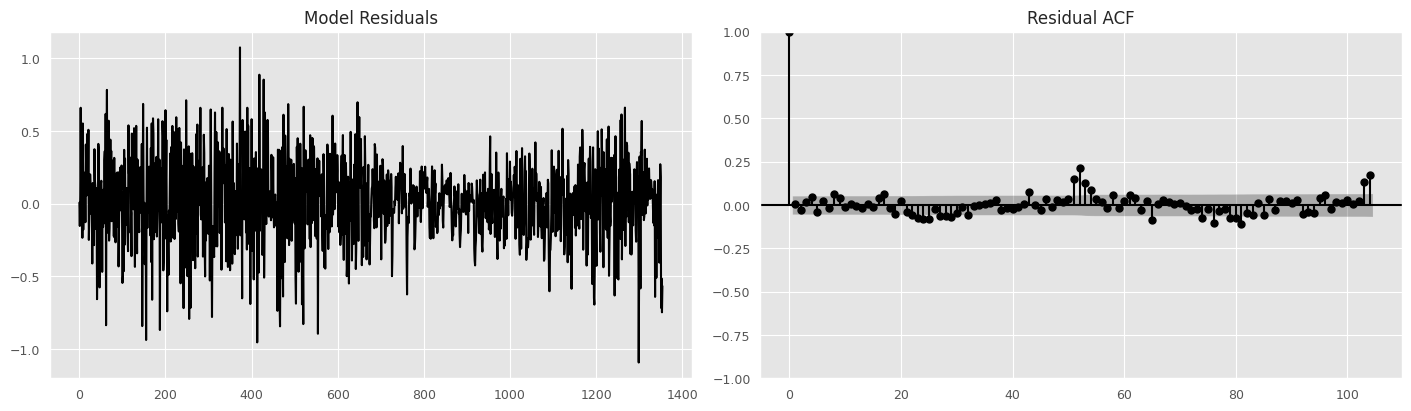

Ljung-Box Test p-value (lag 52): 0.0000
Residuals still contain significant autocorrelation. Consider trimming early 90s data.


In [107]:
# Extract residuals
model_obj = sf.fitted_[0, 0]
residuals = model_obj.model_['residuals']

# Plot residuals and ACF
fig, ax = plt.subplots(1, 2, figsize=(14, 4))
ax[0].plot(residuals)
ax[0].set_title("Model Residuals")
plot_acf(residuals, ax=ax[1], lags=104)
ax[1].set_title("Residual ACF")
plt.show()

# Quick test check
from statsmodels.stats.diagnostic import acorr_ljungbox
lb_pvalue = acorr_ljungbox(residuals, lags=[52], model_df=2).iloc[0, 1]
print(f"Ljung-Box Test p-value (lag 52): {lb_pvalue:.4f}")
if lb_pvalue > 0.05:
    print("Residuals look like White Noise!")
else:
    print("Residuals still contain significant autocorrelation. Consider trimming early 90s data.")

In [108]:
horizon = 52

# 1. Generate future timestamps matching the W-MON frequency
future_dates = pd.date_range(start=df['ds'].max() + pd.Timedelta(weeks=1), periods=horizon, freq='W-MON')

# 2. Construct future exogenous dataframe
last_trend = df['trend'].max()
future_X = pd.DataFrame({
    'unique_id': 'us_gasoline',
    'ds': future_dates,
    'trend': np.arange(last_trend + 1, last_trend + 1 + horizon)
})

# Add the exact same K fourier features to the future dates
future_X = generate_fourier_features(future_X, K=best_k)

# 3. Predict using the future exogenous features
forecast_df = sf.predict(h=horizon, X_df=future_X)

print("\n--- 1 Year Ahead Forecasts ---")
print(forecast_df.head())

ValueError: Expected X to have shape (52, 2), but got (52, 15)

### 6. Electricity consumption is often modelled as a function of temperature. Temperature is measured by daily heating degrees and cooling degrees. Heating degrees is $18^{\circ}\text{C}$ minus the average daily temperature when the daily average is below $18^{\circ}\text{C}$; otherwise it is zero. This provides a measure of our need to heat ourselves as temperature falls. Cooling degrees measures our need to cool ourselves as the temperature rises. It is defined as the average daily temperature minus $18^{\circ}\text{C}$ when the daily average is above $18^{\circ}\text{C}$; otherwise it is zero. Let $y_t$ denote the monthly total of kilowatt-hours of electricity used, let $x_{1,t}$ denote the monthly total of heating degrees, and let $x_{2,t}$ denote the monthly total of cooling degrees.

a. What sort of ARIMA model is identified for $\eta_t$? 

b. Explain what the estimates of $\beta_1~\text{and}~\beta_2$ tell us about electricity consumption.

c. Write the equation in a form more suitable for forecasting.

d. Describe how this model could be used to forecast electricity demand for the next 12 months.

e. Explain why the $\eta_t$ term should be modelled with an ARIMA model rather than modelling the data using a standard regression package. In your discussion, comment on the properties of the estimates, the validity of the standard regression results, and the importance of the $\eta_t$ model in producing forecasts.

### 7. For the retail time series considered in earlier chapters:

a. Develop an appropriate dynamic regression model with Fourier terms for the seasonality. (You will probably need to use the same Box-Cox transformation you identified previously.)

b. Check the residuals of the ARIMA model. Does the residual series look like white noise?

c. Compare the forecasts with those you obtained earlier using alternative models.